<a href="https://colab.research.google.com/github/AhmadKhdair/BinX-AI-ML-Internship/blob/main/week-7/d4/04_Attention_Transformers_HuggingFace.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 - Day 4: Attention, Transformers and Pre-trained NLP

Day 4 moves from the recurrent models from Day 3 to attention-based models. I keep the theory at the level needed for the internship, then use a real text dataset and a pre-trained Hugging Face Transformer for actual inference and evaluation.

The Day 3 ECG sequence dataset is not reused here because it is not text data. This notebook is a separate NLP lab for the Transformer requirement.

## 1. What I Need to Cover Today

The Day 4 requirements are focused on three things: understand the limitation of recurrent processing, understand the core Transformer idea, and use a pre-trained Transformer on a text task.

For this notebook I will:

- connect the RNN/LSTM limitation to attention and self-attention;
- explain why attention helps with long-range context and parallel processing;
- explain the basic Transformer structure and positional information;
- use a pre-trained Transformer through Hugging Face;
- run inference on a real sentiment dataset, not manually written samples;
- evaluate predictions on a fixed subset of the official test split;
- inspect errors and the effect of the model's input-length limit;
- finish with an architecture decision and when a Transformer is or is not a sensible choice.

## 2. From RNN/LSTM to Attention

An RNN processes a sequence one step at a time and passes a hidden state forward. LSTM improves that memory with gates, so it handles long dependencies better than a plain RNN, but the computation is still recurrent: step `t` depends on the state from step `t-1`.

That leaves two limitations. First, information from a distant token still has to travel through a long recurrent path. Second, the sequence positions cannot all be processed independently at the same time because each recurrent state depends on the previous one.

Attention changes that connection pattern. Instead of forcing information to move through a chain of hidden states, a token can assign different relevance weights to other tokens and use the important context directly. **Self-attention** is the case where those tokens come from the same input sequence. This direct access helps with long-range dependencies, and the attention computation across input positions can be parallelized much more effectively than recurrent step-by-step processing.

The important distinction for me is that LSTM improves recurrent memory; attention changes how positions communicate.

## 3. Transformer Idea and Positional Information

A Transformer removes recurrence and builds the sequence representation mainly with self-attention and feed-forward layers. A simplified view for a text classifier is:

`tokens -> token embeddings + position information -> self-attention blocks -> feed-forward blocks -> classification head`

Self-attention by itself does not give the model the same built-in left-to-right order that an RNN gets from recurrence. The model therefore needs **positional information** so that the representation can distinguish where each token appears in the sequence. Different Transformer families can implement this positional information differently; the main point here is that token identity alone is not enough.

For pre-trained models, I do not build these blocks from scratch. I reuse a model that already learned useful language representations and then use the task-specific head that was fine-tuned for classification.

| Model family | Main idea at this level | Typical use |
|---|---|---|
| BERT | Encoder-style Transformer using bidirectional context | Text understanding and classification |
| DistilBERT | Smaller distilled version of BERT | Similar NLP tasks with lower inference cost |
| GPT-2 | Decoder-style autoregressive Transformer | Text generation |

For this task I use DistilBERT because the selected checkpoint already has a binary sentiment-classification head, so I can evaluate a pre-trained Transformer without turning Day 4 into a large fine-tuning experiment.

## 4. Dataset Choice

I compared a few real text-classification datasets before choosing one.

| Dataset | Task | Scale / labels | Fit for this notebook |
|---|---|---|---|
| IMDb Large Movie Review | Review sentiment | 25,000 train + 25,000 test, binary | Strong fit: real reviews, official split, direct sentiment evaluation |
| BANKING77 | Customer-support intent | 13,083 queries, 77 intents | Very realistic, but a fair 77-class evaluation needs task-specific fine-tuning or a heavier zero-shot setup |
| AG News | News topic classification | 120,000 train + 7,600 test, 4 classes | Good dataset, but it needs a topic-classification model rather than the sentiment model used here |

I chose **IMDb**. It is a real review dataset with documented labels and an official train/test split, and sentiment analysis maps to a real product use case such as review monitoring or customer-feedback triage. It also lets me evaluate an existing sentiment Transformer directly, which keeps the work aligned with Day 4 instead of spending the day fine-tuning a large model.

Dataset source: [Stanford NLP IMDb on Hugging Face](https://huggingface.co/datasets/stanfordnlp/imdb)

Other options checked: [BANKING77](https://huggingface.co/datasets/PolyAI/banking77), [AG News](https://huggingface.co/datasets/fancyzhx/ag_news)

## 5. Setup

I pin the two Hugging Face libraries used directly in this notebook so the Colab environment is reproducible. The model itself runs with PyTorch.

In [1]:
!pip -q install transformers==5.16.1 datasets==5.0.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.4 MB/s eta 0:00:00


In [2]:
import re
import time
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import transformers
import datasets

from datasets import load_dataset
from IPython.display import display, Markdown
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from transformers import pipeline

RANDOM_STATE = 42
EVAL_SIZE = 2000
MODEL_NAME = "distilbert/distilbert-base-uncased-finetuned-sst-2-english"

np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.15
PyTorch: 2.11.0+cu128
Transformers: 5.16.1
Datasets: 5.0.1
CUDA available: True
GPU: Tesla T4


## 6. Load the Official IMDb Splits

I use the provided train and test splits instead of creating a new random split. The pre-trained model is not trained or tuned on IMDb in this notebook. I use the training split only for dataset inspection and reserve the official test split for evaluation.

In [3]:
imdb = load_dataset("stanfordnlp/imdb", name="plain_text")
train_ds = imdb["train"]
test_ds = imdb["test"]

print(imdb)
print("Train rows:", len(train_ds))
print("Test rows:", len(test_ds))
print("Label names:", train_ds.features["label"].names)

README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})
Train rows: 25000
Test rows: 25000
Label names: ['neg', 'pos']


## 7. Dataset Audit

Before using the model, I check the label balance, missing or empty text, duplicates, and text lengths. I also look at real examples from both classes. I am not doing stemming, stop-word removal, or aggressive text cleaning because the Transformer was pre-trained to work with normal language and its own tokenizer.

In [4]:
train_df = train_ds.to_pandas()
test_df = test_ds.to_pandas()
label_names = train_ds.features["label"].names

for df in (train_df, test_df):
    df["label_name"] = df["label"].map(dict(enumerate(label_names)))
    df["char_length"] = df["text"].str.len()

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(train_df), len(test_df)],
    "empty_texts": [
        train_df["text"].fillna("").str.strip().eq("").sum(),
        test_df["text"].fillna("").str.strip().eq("").sum(),
    ],
    "duplicate_texts": [
        train_df.duplicated(subset="text").sum(),
        test_df.duplicated(subset="text").sum(),
    ],
    "median_chars": [train_df["char_length"].median(), test_df["char_length"].median()],
    "max_chars": [train_df["char_length"].max(), test_df["char_length"].max()],
})

display(split_summary)

distribution = pd.crosstab(
    train_df["label_name"],
    columns="train_count",
).join(
    pd.crosstab(test_df["label_name"], columns="test_count"),
    how="outer",
)
display(distribution)

,split,rows,empty_texts,duplicate_texts,median_chars,max_chars
0,train,25000,0,96,979.0,13704
1,test,25000,0,199,962.0,12988


col_0,train_count,test_count
label_name,,
neg,12500,12500
pos,12500,12500


In [5]:
sample_reviews = (
    train_df.groupby("label_name", group_keys=False)
    .sample(n=2, random_state=RANDOM_STATE)
    .loc[:, ["label_name", "text"]]
    .copy()
)
sample_reviews["text_preview"] = sample_reviews["text"].str.replace(r"<br\s*/?>", " ", regex=True).str.slice(0, 350)
display(sample_reviews[["label_name", "text_preview"]].reset_index(drop=True))

,label_name,text_preview
0,neg,"Wow, what a total let down! The fact people th..."
1,neg,"If Bob Ludlum was to see this mini series, he ..."
2,pos,I saw The Glacier Fox in the theatre when I ...
3,pos,Reed Hadley makes a better foppish Don Diego t...


The labels are intentionally polarized, so this is a clean binary classification benchmark rather than a full rating-prediction problem. I still check the actual distribution instead of assuming it is balanced from the dataset description.

## 8. Minimal Text Preparation

The raw IMDb reviews contain HTML line-break markers. I remove those markers and normalize repeated whitespace. I keep punctuation, word order, negation, and the rest of the language intact because those are useful signals for the Transformer.

In [6]:
def clean_review(text: str) -> str:
    text = re.sub(r"<br\s*/?>", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["clean_text"] = train_df["text"].map(clean_review)
test_df["clean_text"] = test_df["text"].map(clean_review)

assert train_df["clean_text"].str.len().gt(0).all()
assert test_df["clean_text"].str.len().gt(0).all()

print("Empty cleaned train reviews:", train_df["clean_text"].eq("").sum())
print("Empty cleaned test reviews:", test_df["clean_text"].eq("").sum())

Empty cleaned train reviews: 0
Empty cleaned test reviews: 0


## 9. Fixed Evaluation Sample from the Official Test Split

Running the full 25,000-review test set is possible, but it is unnecessary for this one-day lab. I use a fixed **2,000-review stratified sample** from the official test split so both classes are represented equally and the runtime stays reasonable on Colab.

This sample is not used for training, model selection, or threshold tuning. It is only used once for evaluation of the already selected pre-trained model.

In [7]:
neg = test_df[test_df["label"] == 0].sample(n=EVAL_SIZE // 2, random_state=RANDOM_STATE)
pos = test_df[test_df["label"] == 1].sample(n=EVAL_SIZE // 2, random_state=RANDOM_STATE)

eval_df = (
    pd.concat([neg, pos], axis=0)
    .sample(frac=1.0, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

assert len(eval_df) == EVAL_SIZE
assert eval_df["label"].value_counts().to_dict() == {0: EVAL_SIZE // 2, 1: EVAL_SIZE // 2}

display(eval_df["label_name"].value_counts().rename("count").to_frame())

,count
label_name,
pos,1000
neg,1000


## 10. Load a Pre-trained Transformer with Hugging Face

I use `distilbert-base-uncased-finetuned-sst-2-english`. It is a DistilBERT checkpoint that was fine-tuned on SST-2 for binary sentiment classification. I am evaluating it on IMDb, so this is cross-dataset inference rather than re-evaluating the same training set.

Model source: [DistilBERT SST-2 model card](https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english)

In [8]:
device_id = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    "text-classification",
    model=MODEL_NAME,
    device=device_id,
)

tokenizer = classifier.tokenizer
model = classifier.model
model.eval()

device = next(model.parameters()).device
model_max_length = int(model.config.max_position_embeddings)
MAX_LENGTH = min(512, model_max_length)

print("Device:", device)
print("Model max positions:", model_max_length)
print("Evaluation max length:", MAX_LENGTH)
print("Model labels:", model.config.id2label)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device: cuda:0
Model max positions: 512
Evaluation max length: 512
Model labels: {0: 'NEGATIVE', 1: 'POSITIVE'}


### Pipeline inference on real reviews

The internship requirement asks for practical Hugging Face inference. Instead of writing a few artificial sentences, I take examples directly from the held-out evaluation sample.

In [9]:
demo = eval_df.head(6).copy()
demo_outputs = classifier(
    demo["clean_text"].tolist(),
    truncation=True,
    max_length=MAX_LENGTH,
    batch_size=6,
)

demo["prediction"] = [item["label"] for item in demo_outputs]
demo["confidence"] = [item["score"] for item in demo_outputs]
demo["text_preview"] = demo["clean_text"].str.slice(0, 300)

display(demo[["text_preview", "label_name", "prediction", "confidence"]])

,text_preview,label_name,prediction,confidence
0,Although at times I was the only one in the ci...,pos,POSITIVE,0.999078
1,"I really wanted to love this movie, and not on...",neg,NEGATIVE,0.995704
2,King of the Underworld features an early role ...,pos,POSITIVE,0.993909
3,"If you see the title ""2069 A Sex Odyssey"" in t...",neg,NEGATIVE,0.999567
4,This is definitely an outstanding 1944 musical...,pos,POSITIVE,0.999830
5,Director Don Siegel really impressed me with t...,pos,POSITIVE,0.999232


## 11. Tokenization and Truncation Audit

Transformers do not read strings directly. The tokenizer converts each review into token IDs that match the model vocabulary. For batching, shorter sequences are padded inside each batch; reviews longer than the model limit must be truncated.

Because IMDb reviews can be long, I measure how often that limit is reached instead of silently assuming all text fits.

In [10]:
from transformers.utils import logging as hf_logging

previous_verbosity = hf_logging.get_verbosity()
hf_logging.set_verbosity_error()
token_lengths = np.array([
    len(tokenizer.encode(text, add_special_tokens=True, truncation=False))
    for text in eval_df["clean_text"]
])
hf_logging.set_verbosity(previous_verbosity)

eval_df["token_length"] = token_lengths
eval_df["would_truncate"] = eval_df["token_length"] > MAX_LENGTH

length_summary = pd.Series({
    "min_tokens": int(token_lengths.min()),
    "median_tokens": int(np.median(token_lengths)),
    "p95_tokens": int(np.percentile(token_lengths, 95)),
    "max_tokens": int(token_lengths.max()),
    "reviews_over_limit": int(eval_df["would_truncate"].sum()),
    "truncation_rate": float(eval_df["would_truncate"].mean()),
})
display(length_summary.to_frame("value"))

,value
min_tokens,14.000
median_tokens,221.000
p95_tokens,760.000
max_tokens,1392.000
reviews_over_limit,276.000
truncation_rate,0.138


In [11]:
truncation_rate = eval_df["would_truncate"].mean()
display(Markdown(
    f"On this evaluation sample, **{truncation_rate:.1%}** of reviews exceed the {MAX_LENGTH}-token input limit. "
    "Those reviews are truncated during inference, so the model may not see sentiment cues that appear late in the review."
))

On this evaluation sample, **13.8%** of reviews exceed the 512-token input limit. Those reviews are truncated during inference, so the model may not see sentiment cues that appear late in the review.

## 12. Batched Transformer Evaluation

For the full evaluation I use the model and tokenizer directly. This makes the important parts visible: tokenization, padding, truncation, tensor shapes, `eval()` mode, `torch.inference_mode()`, softmax probabilities, and label mapping.

No gradients or training are needed because this is inference with a pre-trained classifier.

In [12]:
BATCH_SIZE = 16 if device.type == "cuda" else 8

id2label = {int(k): str(v).upper() for k, v in model.config.id2label.items()}
positive_class_id = next(i for i, label in id2label.items() if "POS" in label)

all_pred_ids = []
all_positive_scores = []

if device.type == "cuda":
    torch.cuda.synchronize()
start = time.perf_counter()

with torch.inference_mode():
    for start_idx in range(0, len(eval_df), BATCH_SIZE):
        batch_texts = eval_df["clean_text"].iloc[start_idx:start_idx + BATCH_SIZE].tolist()
        encoded = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt",
        )
        encoded = {name: tensor.to(device) for name, tensor in encoded.items()}

        logits = model(**encoded).logits
        probabilities = torch.softmax(logits, dim=-1)

        all_pred_ids.extend(logits.argmax(dim=-1).cpu().tolist())
        all_positive_scores.extend(probabilities[:, positive_class_id].cpu().tolist())

if device.type == "cuda":
    torch.cuda.synchronize()
elapsed_seconds = time.perf_counter() - start

pred_binary = np.array([
    1 if "POS" in id2label[pred_id] else 0
    for pred_id in all_pred_ids
])
positive_scores = np.array(all_positive_scores)
true_binary = eval_df["label"].to_numpy()

eval_df["pred_label"] = pred_binary
eval_df["pred_name"] = np.where(pred_binary == 1, "pos", "neg")
eval_df["positive_score"] = positive_scores
eval_df["correct"] = eval_df["pred_label"] == eval_df["label"]
eval_df["prediction_confidence"] = np.maximum(positive_scores, 1 - positive_scores)

print("Predictions:", len(pred_binary))
print("Inference seconds:", round(elapsed_seconds, 2))
print("Reviews per second:", round(len(eval_df) / elapsed_seconds, 2))

Predictions: 2000
Inference seconds: 34.78
Reviews per second: 57.5


## 13. Metrics

The test sample is balanced, so accuracy is easy to interpret, but I also report precision, recall, F1, and ROC-AUC. The probability for the positive class is used for ROC-AUC rather than the hard class prediction.

In [13]:
accuracy = accuracy_score(true_binary, pred_binary)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_binary,
    pred_binary,
    average="binary",
    zero_division=0,
)
roc_auc = roc_auc_score(true_binary, positive_scores)

metrics_df = pd.DataFrame({
    "metric": ["accuracy", "precision", "recall", "f1", "roc_auc"],
    "value": [accuracy, precision, recall, f1, roc_auc],
})
display(metrics_df.round(4))

print(classification_report(
    true_binary,
    pred_binary,
    target_names=["negative", "positive"],
    digits=4,
    zero_division=0,
))

,metric,value
0,accuracy,0.8925
1,precision,0.9198
2,recall,0.8600
3,f1,0.8889
4,roc_auc,0.9584


              precision    recall  f1-score   support

    negative     0.8685    0.9250    0.8959      1000
    positive     0.9198    0.8600    0.8889      1000

    accuracy                         0.8925      2000
   macro avg     0.8942    0.8925    0.8924      2000
weighted avg     0.8942    0.8925    0.8924      2000



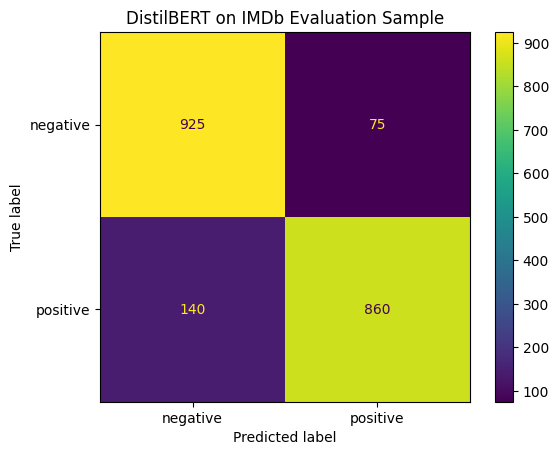

In [14]:
ConfusionMatrixDisplay.from_predictions(
    true_binary,
    pred_binary,
    display_labels=["negative", "positive"],
    values_format="d",
)
plt.title("DistilBERT on IMDb Evaluation Sample")
plt.show()

In [15]:
display(Markdown(
    f"The pre-trained DistilBERT model reached **{accuracy:.3f} accuracy**, **{f1:.3f} F1**, "
    f"and **{roc_auc:.3f} ROC-AUC** on the fixed {len(eval_df):,}-review IMDb test sample. "
    "These numbers come from the executed predictions above; they are not copied from the model card."
))

The pre-trained DistilBERT model reached **0.892 accuracy**, **0.889 F1**, and **0.958 ROC-AUC** on the fixed 2,000-review IMDb test sample. These numbers come from the executed predictions above; they are not copied from the model card.

## 14. Error Analysis

Accuracy alone does not show why the model fails. I inspect incorrect predictions with the highest confidence because these are the cases where the model was most certain and still wrong. This can expose negation, mixed sentiment, truncation, sarcasm, or domain differences.

In [16]:
errors = (
    eval_df.loc[~eval_df["correct"], [
        "clean_text",
        "label_name",
        "pred_name",
        "prediction_confidence",
        "token_length",
        "would_truncate",
    ]]
    .sort_values("prediction_confidence", ascending=False)
    .head(10)
    .copy()
)
errors["text_preview"] = errors["clean_text"].str.slice(0, 500)

display(errors[[
    "text_preview",
    "label_name",
    "pred_name",
    "prediction_confidence",
    "token_length",
    "would_truncate",
]])

,text_preview,label_name,pred_name,prediction_confidence,token_length,would_truncate
674,I really liked this quirky movie. The characte...,neg,pos,0.999864,54,False
970,Not the funniest movie ever.....but I have to ...,neg,pos,0.999750,60,False
1990,"After seeing Forever Hollywood, it would be na...",neg,pos,0.999612,93,False
1971,"To surmise, this film involves two actors (Cai...",pos,neg,0.999608,162,False
861,I enjoyed the beautiful scenery in this movie ...,neg,pos,0.999601,118,False
1810,Oh boy ! It was just a dream ! What a great id...,neg,pos,0.999520,69,False
1476,This was a very nice concert by the one and on...,neg,pos,0.999443,154,False
1482,This was Laurel and Hardy's last silent film f...,pos,neg,0.999355,270,False
763,Others' main criticism of this film--namely th...,pos,neg,0.999327,260,False
482,As long as you keep in mind that the productio...,neg,pos,0.999325,298,False


In [17]:
error_rate = 1 - eval_df["correct"].mean()
truncated_error_rate = (
    1 - eval_df.loc[eval_df["would_truncate"], "correct"].mean()
    if eval_df["would_truncate"].any()
    else np.nan
)
non_truncated_error_rate = 1 - eval_df.loc[~eval_df["would_truncate"], "correct"].mean()

error_summary = pd.DataFrame({
    "group": ["all", "truncated", "not_truncated"],
    "error_rate": [error_rate, truncated_error_rate, non_truncated_error_rate],
    "samples": [
        len(eval_df),
        int(eval_df["would_truncate"].sum()),
        int((~eval_df["would_truncate"]).sum()),
    ],
})
display(error_summary.round(4))

,group,error_rate,samples
0,all,0.1075,2000
1,truncated,0.1341,276
2,not_truncated,0.1032,1724


The truncation comparison is descriptive, not proof that truncation causes an error. Long reviews can be harder for other reasons too. I use it only to check whether input length is a visible failure mode worth investigating.

## 15. Attention / Transformer vs. RNN/LSTM Memory

An RNN or LSTM carries information forward through a recurrent hidden state. LSTM makes that memory more stable with gates, but processing still follows the sequence step by step. A Transformer removes that recurrence. With self-attention, each input position can use weighted information from other positions directly, so distant context does not need to pass through the same long chain of recurrent states. For an encoder-style classification model such as DistilBERT, the input positions can also be processed much more in parallel than recurrent time steps. Positional information is added because the model no longer gets sequence order from recurrence itself.

## 16. Architecture Decision

For **this sentiment-analysis lab**, a pre-trained Transformer is a good fit because the input is text, context and word relationships matter, and a task-specific sentiment checkpoint is already available. Training a Transformer from scratch would not be justified for this Day 4 task.

I am **not** comparing the IMDb Transformer metric with the Day 3 ECG LSTM metric. They are different datasets and different prediction tasks, so that would be an invalid comparison. If I wanted a real LSTM-vs-Transformer comparison, both models would need to be trained/evaluated on the same text split with the same metric.

For my tabular heart-disease capstone, neither an LSTM nor a Transformer becomes the core model just because I studied them this week. The architecture should still match the data type. A Transformer is a sensible choice for text and other sequence problems where context matters and enough compute or a suitable pre-trained model exists. It is usually not the first choice for ordinary small tabular data, and it can also be unnecessary when a simpler model already solves the task with lower latency, memory, and deployment cost.

## 17. Day 4 Final Audit

The last cell checks the concrete notebook requirements that can be verified from the executed state. If any earlier model or dataset cell failed, the notebook will not reach this point cleanly.

In [18]:
audit = pd.DataFrame([
    {"requirement": "Real documented text dataset", "status": len(train_df) == 25000 and len(test_df) == 25000},
    {"requirement": "Official train/test split preserved", "status": len(test_df) == 25000},
    {"requirement": "Hugging Face pre-trained Transformer loaded", "status": model is not None and tokenizer is not None},
    {"requirement": "Pipeline inference on real dataset text", "status": len(demo_outputs) == len(demo)},
    {"requirement": "Tokenization and truncation handled", "status": MAX_LENGTH <= model_max_length},
    {"requirement": "Model in eval mode", "status": not model.training},
    {"requirement": "Real held-out predictions produced", "status": len(pred_binary) == EVAL_SIZE},
    {"requirement": "Accuracy / precision / recall / F1 / ROC-AUC computed", "status": metrics_df["value"].notna().all()},
    {"requirement": "Error analysis completed", "status": "correct" in eval_df.columns},
    {"requirement": "No ECG data used for the NLP task", "status": True},
])

display(audit)

if not audit["status"].all():
    raise RuntimeError("Day 4 audit failed. Check the rows marked False before submission.")

print("Day 4 execution audit passed.")

,requirement,status
0,Real documented text dataset,True
1,Official train/test split preserved,True
2,Hugging Face pre-trained Transformer loaded,True
3,Pipeline inference on real dataset text,True
4,Tokenization and truncation handled,True
5,Model in eval mode,True
6,Real held-out predictions produced,True
7,Accuracy / precision / recall / F1 / ROC-AUC c...,True
8,Error analysis completed,True
9,No ECG data used for the NLP task,True


Day 4 execution audit passed.
